In [1]:
!pip install -q torch torchvision scikit-learn matplotlib pandas


In [2]:
import os, time, copy, random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.transforms import InterpolationMode

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


## 0.1 Mount Google Drive and set up output folders

In [3]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = "/content/drive/MyDrive/CO3133_Assignments"
except ImportError:
    DRIVE_ROOT = "."

OUTPUT_DIR = os.path.join(DRIVE_ROOT, "A1_Foundations_FashionMNIST")
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
CKPT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")
RESULTS_DIR = os.path.join(OUTPUT_DIR, "results")

for d in (FIG_DIR, CKPT_DIR, RESULTS_DIR):
    os.makedirs(d, exist_ok=True)

print("Saving all outputs under:", OUTPUT_DIR)


Mounted at /content/drive
Saving all outputs under: /content/drive/MyDrive/CO3133_Assignments/A1_Foundations_FashionMNIST


In [4]:
import platform
env_info = {
    "seed": SEED,
    "python_version": platform.python_version(),
    "torch_version": torch.__version__,
    "torchvision_version": torchvision.__version__,
    "device": str(DEVICE),
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A (CPU run)",
    "platform": platform.platform(),
}
for k, v in env_info.items():
    print(f"{k}: {v}")


seed: 42
python_version: 3.13.15
torch_version: 2.11.0+cu128
torchvision_version: 0.26.0+cu128
device: cuda
gpu_name: Tesla T4
platform: Linux-6.6.122+-x86_64-with-glibc2.39


## 1. Data loading



In [13]:
mnist_debug_train = torchvision.datasets.MNIST(root="./data", train=True, download=True)
print("MNIST debug set:", len(mnist_debug_train), "images")

fmnist_train_raw = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True
)
fmnist_test_raw = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True
)

print("Official train pool:", len(fmnist_train_raw))
print("Official test set:", len(fmnist_test_raw))

train_images_all = fmnist_train_raw.data.numpy()
train_labels_all = fmnist_train_raw.targets.numpy()
test_images = fmnist_test_raw.data.numpy()
test_labels = fmnist_test_raw.targets.numpy()

assert train_images_all.shape == (60_000, 28, 28), "Unexpected official training-pool shape"
assert train_labels_all.shape == (60_000,), "Image/label count mismatch"
assert train_images_all.dtype == np.uint8, "Expected raw uint8 pixels"
assert np.isfinite(train_images_all).all(), "Non-finite pixel detected"
assert np.array_equal(np.unique(train_labels_all), np.arange(10)), "Labels must cover integers 0 through 9"

assert test_images.shape == (10_000, 28, 28), "Unexpected official test-pool shape"
assert test_labels.shape == (10_000,), "Image/label count mismatch"
assert test_images.dtype == np.uint8, "Expected raw uint8 pixels"
assert np.isfinite(test_images).all(), "Non-finite pixel detected"
assert np.array_equal(np.unique(test_labels), np.arange(10)), "Labels must cover integers 0 through 9"

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_all)),
    test_size=0.2,
    stratify=train_labels_all,
    random_state=SEED,
)
train_images, train_labels = train_images_all[train_idx], train_labels_all[train_idx]
val_images, val_labels = train_images_all[val_idx], train_labels_all[val_idx]

print("Official training pool:", train_images_all.shape, train_labels_all.shape)
print(f"Canonical development split: train={len(train_images):,}, val={len(val_images):,}, seed={SEED}")


MNIST debug set: 60000 images
Official train pool: 60000
Official test set: 10000
Official training pool: (60000, 28, 28) (60000,)
Canonical development split: train=48,000, val=12,000, seed=42


## 2. Exploratory Data Analysis (EDA)




In [14]:
class_ids, counts = np.unique(train_labels, return_counts=True)
CLASS_NAMES = list(fmnist_train_raw.classes)
NUM_CLASSES = len(class_ids)

if len(CLASS_NAMES) != NUM_CLASSES:
    raise ValueError("Dataset class names do not match the labels found in the training data.")

print(f"Detected {NUM_CLASSES} classes from the training data.")

h, w = train_images.shape[1:]
assert train_images.shape[1:] == (28, 28), "Training image shape mismatch!"
assert not np.isnan(train_images).any(), "Corrupted NaN pixel detected in training split!"

def get_dir_size_mb(path):
    total = 0
    if os.path.exists(path):
        for root, _, files in os.walk(path):
            for f in files:
                total += os.path.getsize(os.path.join(root, f))
    return total / 1e6

data_size_mb = get_dir_size_mb("./data")

print(f"Official dataset metadata: {len(fmnist_train_raw):,} train-pool + {len(fmnist_test_raw):,} test samples")
print(f"Development EDA scope    : {len(train_images):,} training samples only")
print(f"Validation reserved      : {len(val_images):,} samples (not used for EDA)")
print(f"Input dimensions         : {h} x {w} x 1 (grayscale), dtype: {train_images.dtype}, range: [{train_images.min()}, {train_images.max()}]")
print(f"Current local cache size  : {data_size_mb:.1f} MB")

Detected 10 classes from the training data.
Official dataset metadata: 60,000 train-pool + 10,000 test samples
Development EDA scope    : 48,000 training samples only
Validation reserved      : 12,000 samples (not used for EDA)
Input dimensions         : 28 x 28 x 1 (grayscale), dtype: uint8, range: [0, 255]
Current local cache size  : 152.4 MB


Class distribution summary:
 class_id  class_name  train_count  train_pct  validation_count  validation_pct
        0 T-shirt/top         4800       10.0              1200            10.0
        1     Trouser         4800       10.0              1200            10.0
        2    Pullover         4800       10.0              1200            10.0
        3       Dress         4800       10.0              1200            10.0
        4        Coat         4800       10.0              1200            10.0
        5      Sandal         4800       10.0              1200            10.0
        6       Shirt         4800       10.0              1200            10.0
        7     Sneaker         4800       10.0              1200            10.0
        8         Bag         4800       10.0              1200            10.0
        9  Ankle boot         4800       10.0              1200            10.0

Max/min class count ratio (imbalance ratio): 1.0000
Perfectly balanced across classes: True

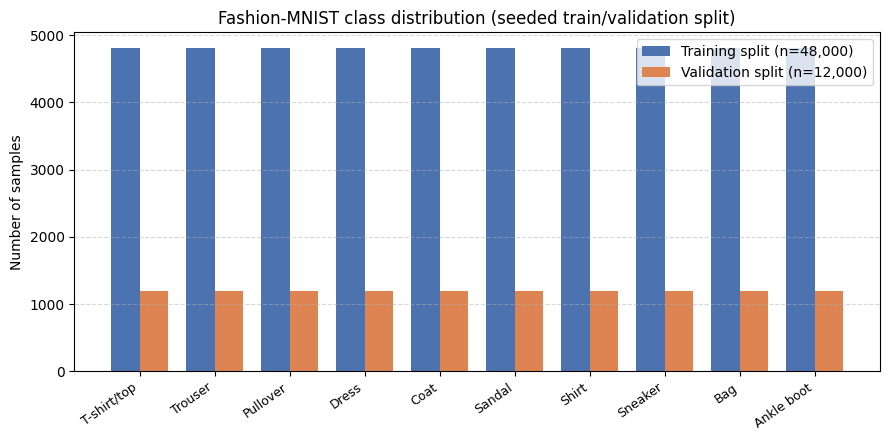

In [15]:
val_counts = np.bincount(val_labels, minlength=NUM_CLASSES)

dist_df = pd.DataFrame({
    "class_id": class_ids,
    "class_name": CLASS_NAMES,
    "train_count": counts,
    "train_pct": 100 * counts / counts.sum(),
    "validation_count": val_counts,
    "validation_pct": 100 * val_counts / val_counts.sum(),
})
print("Class distribution summary:")
print(dist_df.to_string(index=False))

imbalance_ratio = dist_df['train_count'].max() / dist_df['train_count'].min()
is_balanced = (counts.std() == 0) and (val_counts.std() == 0)
print(f"\nMax/min class count ratio (imbalance ratio): {imbalance_ratio:.4f}")
print(f"Perfectly balanced across classes: {is_balanced} (std = {counts.std():.1f})")

x = np.arange(NUM_CLASSES)
width = 0.38
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - width/2, counts, width, label=f"Training split (n={counts.sum():,})", color="#4C72B0")
ax.bar(x + width/2, val_counts, width, label=f"Validation split (n={val_counts.sum():,})", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Number of samples")
ax.set_title("Fashion-MNIST class distribution (seeded train/validation split)")
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_eda_class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

Raw pixel mean (0-255)  = 72.99, std = 90.06
Normalized mean [0-1]   = 0.2863, std = 0.3532
Fraction of background (value = 0) pixels = 50.2%


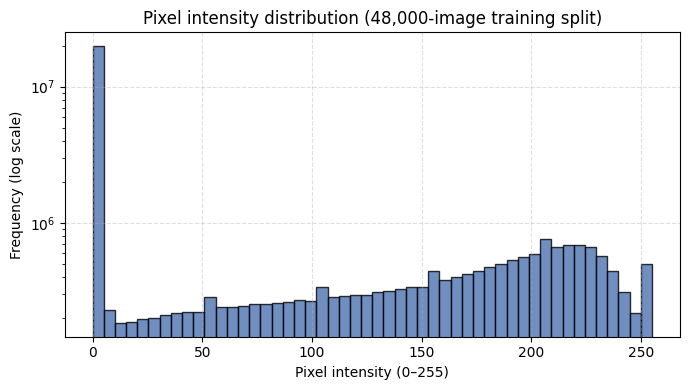

In [16]:
raw_mean = float(train_images.mean())
raw_std = float(train_images.std())
bg_frac = float((train_images == 0).mean())

print(f"Raw pixel mean (0-255)  = {raw_mean:.2f}, std = {raw_std:.2f}")
print(f"Normalized mean [0-1]   = {raw_mean / 255.0:.4f}, std = {raw_std / 255.0:.4f}")
print(f"Fraction of background (value = 0) pixels = {bg_frac * 100:.1f}%")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(train_images.flatten(), bins=50, color="#4C72B0", edgecolor="black", alpha=0.8)
ax.set_yscale("log")
ax.set_xlabel("Pixel intensity (0–255)")
ax.set_ylabel("Frequency (log scale)")
ax.set_title("Pixel intensity distribution (48,000-image training split)")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_eda_pixel_intensity.png"), dpi=150, bbox_inches="tight")
plt.show()

In [17]:
per_class_mean = [float(train_images[train_labels == c].mean()) for c in range(NUM_CLASSES)]
intensity_df = pd.DataFrame({
    "class_id": range(NUM_CLASSES),
    "class_name": CLASS_NAMES,
    "mean_pixel_intensity": per_class_mean
}).sort_values(by="mean_pixel_intensity", ascending=True)

print("Per-class mean pixel intensity (proxy for foreground silhouette frame coverage):")
print(intensity_df.to_string(index=False))

print(f"\n[Silhouette Observation]: Footwear (Sandal: {per_class_mean[5]:.2f}, Sneaker: {per_class_mean[7]:.2f}) has low mean intensity due to wide empty margins,")
print(f"while heavy upper garments (Pullover: {per_class_mean[2]:.2f}, Coat: {per_class_mean[4]:.2f}) have high intensity as they fill most of the 28x28 frame.")

Per-class mean pixel intensity (proxy for foreground silhouette frame coverage):
 class_id  class_name  mean_pixel_intensity
        5      Sandal             34.800133
        7     Sneaker             42.837788
        1     Trouser             56.987135
        3       Dress             66.121778
        9  Ankle boot             76.760902
        0 T-shirt/top             82.849735
        6       Shirt             84.826124
        8         Bag             90.169411
        2    Pullover             96.491521
        4        Coat             98.100238

[Silhouette Observation]: Footwear (Sandal: 34.80, Sneaker: 42.84) has low mean intensity due to wide empty margins,
while heavy upper garments (Pullover: 96.49, Coat: 98.10) have high intensity as they fill most of the 28x28 frame.


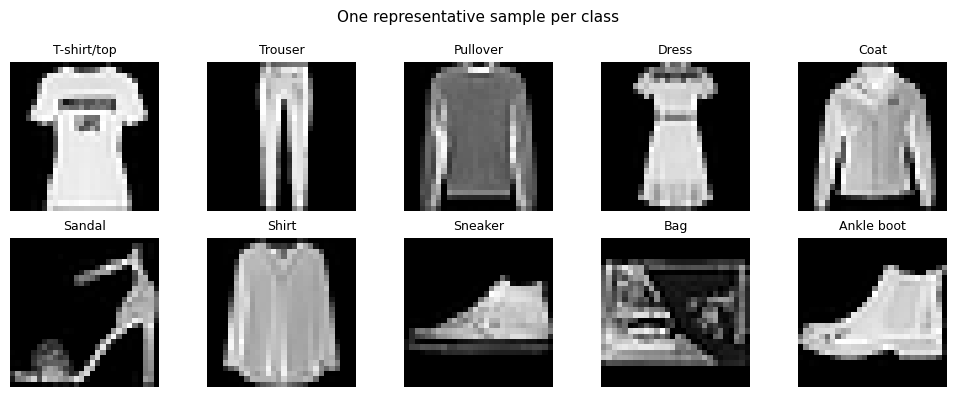

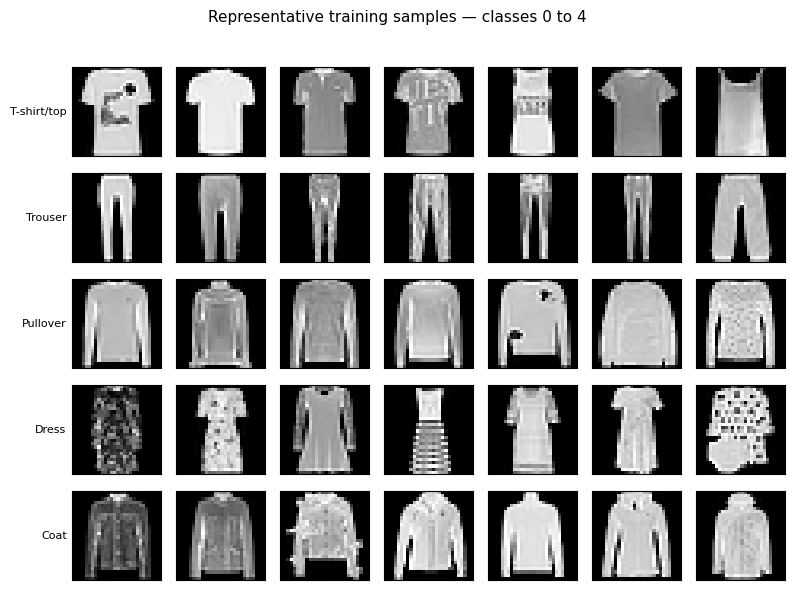

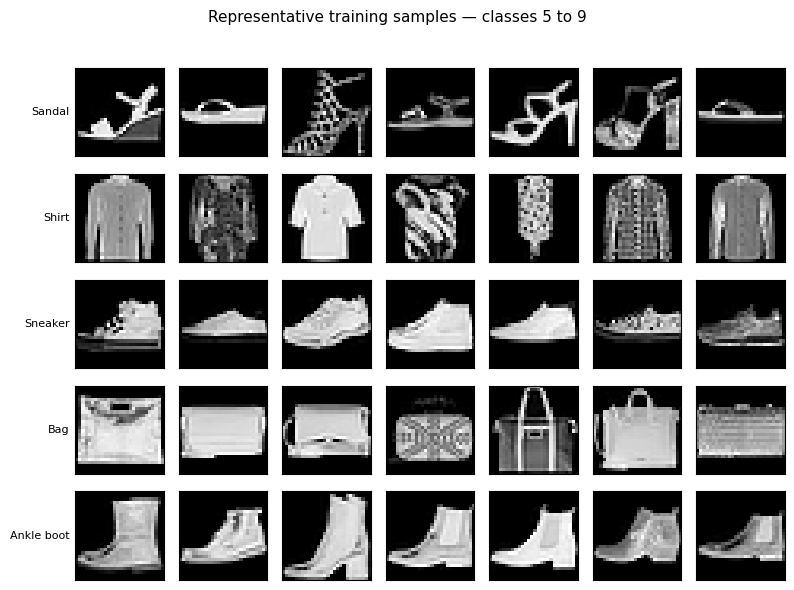

Training-only pixel mean = 0.2863, pixel std = 0.3532


In [18]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for c in range(NUM_CLASSES):
    idx = np.where(train_labels == c)[0][0]
    ax = axes[c // 5, c % 5]
    ax.imshow(train_images[idx], cmap="gray")
    ax.set_title(CLASS_NAMES[c], fontsize=9)
    ax.axis("off")
plt.suptitle("One representative sample per class", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_eda_representative_samples.png"), dpi=150, bbox_inches="tight")
plt.show()

rng_eda = np.random.default_rng(SEED)
N_PER_CLASS = 7
CLASS_GROUPS = [range(0, 5), range(5, 10)]

for g, class_group in enumerate(CLASS_GROUPS, start=1):
    class_group = list(class_group)
    fig, axes = plt.subplots(len(class_group), N_PER_CLASS,
                             figsize=(N_PER_CLASS * 1.15, len(class_group) * 1.15))
    for row, c in enumerate(class_group):
        idxs = np.where(train_labels == c)[0]
        chosen = rng_eda.choice(idxs, size=N_PER_CLASS, replace=False)
        for j, idx in enumerate(chosen):
            ax = axes[row, j]
            ax.imshow(train_images[idx], cmap="gray", vmin=0, vmax=255)
            ax.set_xticks([]); ax.set_yticks([])
            if j == 0:
                ax.set_ylabel(CLASS_NAMES[c], fontsize=8, rotation=0, ha="right", va="center")
    plt.suptitle(f"Representative training samples — classes {class_group[0]} to {class_group[-1]}",
                 y=1.02, fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"01_eda_samples_classes_{class_group[0]}-{class_group[-1]}.png"), dpi=150, bbox_inches="tight")
    plt.show()

pixel_mean = float((train_images / 255.0).mean())
pixel_std = float((train_images / 255.0).std())
print(f"Training-only pixel mean = {pixel_mean:.4f}, pixel std = {pixel_std:.4f}")

In [19]:
assert len(train_images) == 48_000 and len(val_images) == 12_000
assert np.all(np.bincount(train_labels, minlength=10) == 4_800)
assert np.all(np.bincount(val_labels, minlength=10) == 1_200)
print(f"train: {train_images.shape[0]} | val: {val_images.shape[0]} | official test: {len(fmnist_test_raw)}")
print("Split seed:", SEED, "| Stratified by label: yes | Split unit: one image = one sample")
print(f"Normalization mean = {pixel_mean:.4f}, std = {pixel_std:.4f} (training split only)")

train: 48000 | val: 12000 | official test: 10000
Split seed: 42 | Stratified by label: yes | Split unit: one image = one sample
Normalization mean = 0.2863, std = 0.3532 (training split only)


## 4. Preprocessing, Dataset and DataLoader




In [ ]:
class ArrayImageDataset(Dataset):
    def __init__(self, images, labels, transform):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx]).convert("L")
        label = int(self.labels[idx])
        return self.transform(img), label

train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=(-10, 10)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(size=28, padding=2),
    transforms.ToTensor(),
    transforms.Normalize((pixel_mean,), (pixel_std,)),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((pixel_mean,), (pixel_std,)),
])

BATCH_SIZE = 128

train_ds = ArrayImageDataset(train_images, train_labels, train_transform)
val_ds = ArrayImageDataset(val_images, val_labels, eval_transform)
test_ds = ArrayImageDataset(test_images, test_labels, eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2)

xb, yb = next(iter(train_loader))
print("One preprocessed batch image shape:", xb.shape)
print("One preprocessed batch label shape:", yb.shape)


One preprocessed batch image shape: torch.Size([128, 1, 28, 28])
One preprocessed batch label shape: torch.Size([128])


## 5. Shared training / evaluation utilities



In [ ]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def compute_class_metrics(y_true, y_pred, class_names=CLASS_NAMES):
    prec_per_class = precision_score(y_true, y_pred, average=None, zero_division=0)
    rec_per_class = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1_per_class = f1_score(y_true, y_pred, average=None, zero_division=0)

    rows = []
    for c in range(len(class_names)):
        acc_c = ((y_pred == c) == (y_true == c)).mean()
        support_c = (y_true == c).sum()
        rows.append({
            "Class ID": c,
            "Class Name": class_names[c],
            "Accuracy": round(float(acc_c), 4),
            "Precision": round(float(prec_per_class[c]), 4),
            "Recall": round(float(rec_per_class[c]), 4),
            "F1-Score": round(float(f1_per_class[c]), 4),
            "Support": int(support_c),
        })

    df = pd.DataFrame(rows)
    macro_row = pd.DataFrame([{
        "Class ID": "-",
        "Class Name": "Macro Average",
        "Accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
        "Precision": round(float(prec_per_class.mean()), 4),
        "Recall": round(float(rec_per_class.mean()), 4),
        "F1-Score": round(float(f1_per_class.mean()), 4),
        "Support": int(len(y_true)),
    }])

    return pd.concat([df, macro_row], ignore_index=True)


def fit(model, dataloader, criterion, optimizer, device=DEVICE):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        all_preds.append(outputs.argmax(dim=1).detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)
    epoch_loss = running_loss / len(dataloader.dataset)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    return epoch_loss, acc, prec, rec, macro_f1, y_true, y_pred


@torch.no_grad()
def evaluate(model, dataloader, criterion, device=DEVICE):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        all_preds.append(outputs.argmax(dim=1).detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)
    epoch_loss = running_loss / len(dataloader.dataset)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    return epoch_loss, acc, prec, rec, macro_f1, y_true, y_pred


def run_one_epoch(model, train_loader, val_loader, criterion, optimizer, device=DEVICE):
    train_loss, train_acc, train_prec, train_rec, train_f1, _, _ = fit(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_prec, val_rec, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
    return (train_loss, train_acc, train_prec, train_rec, train_f1,
            val_loss, val_acc, val_prec, val_rec, val_f1)


def run_epoch(model, loader, criterion, optimizer=None, desc=None):
    if optimizer is not None:
        return fit(model, loader, criterion, optimizer, DEVICE)
    else:
        return evaluate(model, loader, criterion, DEVICE)


def train_model(model, name, epochs=15, lr=1e-3, patience=3, history=None,
                optimizer_state_dict=None, scheduler_state_dict=None,
                best_val_loss=None, start_epoch=None):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3, threshold=1e-4,
        threshold_mode="abs", min_lr=1e-6
    )

    if optimizer_state_dict is not None:
        optimizer.load_state_dict(optimizer_state_dict)
    if scheduler_state_dict is not None:
        scheduler.load_state_dict(scheduler_state_dict)

    if history is None:
        history = {"train_loss": [], "train_acc": [], "train_prec": [], "train_rec": [], "train_f1": [],
                   "val_loss": [], "val_acc": [], "val_prec": [], "val_rec": [], "val_f1": []}
    else:
        history = copy.deepcopy(history)

    start_epoch = len(history.get("train_loss", [])) if start_epoch is None else int(start_epoch)
    if best_val_loss is None:
        best_val_loss = min(history.get("val_loss", [])) if history.get("val_loss") else float("inf")

    best_state = copy.deepcopy(model.state_dict())
    best_optimizer_state = copy.deepcopy(optimizer.state_dict())
    best_scheduler_state = copy.deepcopy(scheduler.state_dict())
    bad_epochs = 0

    t0 = time.time()
    for local_epoch in range(1, epochs + 1):
        train_loss, train_acc, train_prec, train_rec, train_f1, val_loss, val_acc, val_prec, val_rec, val_f1 = run_one_epoch(
            model, train_loader, val_loader, criterion, optimizer, DEVICE
        )
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss); history["train_acc"].append(train_acc)
        history["train_prec"].append(train_prec); history["train_rec"].append(train_rec); history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)
        history["val_prec"].append(val_prec); history["val_rec"].append(val_rec); history["val_f1"].append(val_f1)

        epoch = start_epoch + local_epoch
        print(f"[{name}] Epoch {epoch:03d} | Train Loss: {train_loss:.4f} - Acc: {train_acc:.4f} - F1: {train_f1:.4f} | "
              f"Val Loss: {val_loss:.4f} - Acc: {val_acc:.4f} - F1: {val_f1:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_optimizer_state = copy.deepcopy(optimizer.state_dict())
            best_scheduler_state = copy.deepcopy(scheduler.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"[{name}] early stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
                break

    train_time = time.time() - t0
    model.load_state_dict(best_state)
    optimizer.load_state_dict(best_optimizer_state)
    scheduler.load_state_dict(best_scheduler_state)

    training_state = {
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val_loss": float(best_val_loss),
        "epochs_run": len(history.get("train_loss", [])),
    }
    return model, history, train_time, training_state

def measure_inference_time(model, loader, n_warmup_batches=2):
    model.eval()
    device_sync = torch.cuda.synchronize if DEVICE.type == "cuda" else (lambda: None)

    with torch.no_grad():
        for i, (xb, _) in enumerate(loader):
            if i >= n_warmup_batches:
                break
            _ = model(xb.to(DEVICE))

    device_sync()
    t0 = time.time()
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(DEVICE)
            _ = model(xb)
    device_sync()
    total_time = time.time() - t0
    return 1000 * total_time / len(loader.dataset)


## 6. Model 1 — Linear / Softmax classifier




In [ ]:
class LinearClassifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, input_dim=28 * 28):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.fc(x)


## 7. Model 2 — Multilayer Perceptron (MLP)



In [ ]:
class MLP(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, input_dim=28 * 28, hidden_dims=(256, 128, 64), dropout=0.3):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(inplace=True), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)


## 8. Model 3 — Convolutional Neural Network (CNN)


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),nn.Dropout2d(0.25),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),nn.Dropout2d(0.25),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),nn.Dropout2d(0.3),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(128, 64), nn.ReLU(inplace=True), nn.Dropout(0.3), nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


## 11. Checkpoint registry

In [ ]:
import pickle

MODEL_BUILDERS = {
    "Linear": lambda: LinearClassifier(),
    "MLP": lambda: MLP(),
    "CNN": lambda: SimpleCNN()

}

CHECKPOINT_TAG = "200K_v4"

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

def checkpoint_path(name):
    return os.path.join(CKPT_DIR, f"{name}_{CHECKPOINT_TAG}.pt")

def find_existing_checkpoint(name):
    path = checkpoint_path(name)
    return path if os.path.exists(path) else None

def format_time(seconds):
    seconds = float(seconds)
    if seconds < 60: return f"{seconds:.1f}s"
    minutes, seconds = divmod(seconds, 60)
    if minutes < 60: return f"{int(minutes)}m {seconds:.1f}s"
    hours, minutes = divmod(minutes, 60)
    return f"{int(hours)}h {int(minutes)}m {seconds:.1f}s"

def load_model_checkpoint(name, device=DEVICE):
    if name not in MODEL_BUILDERS:
        raise ValueError(f"Unknown model '{name}'. Available: {list(MODEL_BUILDERS)}")

    path = find_existing_checkpoint(name)
    if path is None:
        raise FileNotFoundError(f"No checkpoint found for {name}: {checkpoint_path(name)}")

    ckpt = torch.load(path, map_location=device, weights_only=False)
    model = MODEL_BUILDERS[name]().to(device)
    state_dict = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt

    try:
        model.load_state_dict(state_dict)
    except RuntimeError as e:
        raise RuntimeError(
            f"Checkpoint '{path}' is incompatible with the current {name} architecture. "
        ) from e

    model.eval()
    return model, ckpt, path

print("Checkpoint directory:", CKPT_DIR)
for name in MODEL_BUILDERS:
    path = find_existing_checkpoint(name)
    print(f"{name}: {'FOUND -> ' + path if path else 'NOT FOUND'}")


Checkpoint directory: /content/drive/MyDrive/CO3133_Assignments/A1_Foundations_FashionMNIST/checkpoints
Linear: NOT FOUND
MLP: NOT FOUND
CNN: NOT FOUND


## 12. Optional training / resume

This section is optional. Set `TRAIN_MODELS = False` to load checkpoints and run inference.

- `FORCE_RETRAIN = True`: ignore an existing checkpoint and train from scratch.
- `FORCE_RETRAIN = False`: if a checkpoint exists, continue training from its saved weights/history; otherwise train from scratch.
- New checkpoints also save optimizer/scheduler state. Older checkpoints without those states still resume from the saved weights using `RESUME_LR`.


In [ ]:
TRAIN_MODELS = True
MODELS_TO_TRAIN = ["Linear", "MLP", "CNN"]
EPOCHS = 200
CONTINUE_EPOCHS = 50
LR = 1e-3
RESUME_LR = 1e-4
PATIENCE = 8
FORCE_RETRAIN = True

if not TRAIN_MODELS:
    print("Training skipped")
else:
    for name in MODELS_TO_TRAIN:
        if name not in MODEL_BUILDERS: raise ValueError(f"{name} is not enabled in MODEL_BUILDERS")
        path = find_existing_checkpoint(name)
        resume = path is not None and not FORCE_RETRAIN

        if resume:
            print(f"\nResuming [{name}] from: {path}")
            model, ckpt, _ = load_model_checkpoint(name)
            seed = ckpt.get("seed", SEED) if isinstance(ckpt, dict) else SEED
            old_history = ckpt.get("history", None) if isinstance(ckpt, dict) else None
            old_total_time = float(ckpt.get("total_train_time_sec", ckpt.get("train_time_sec", 0.0))) if isinstance(ckpt, dict) else 0.0
            optimizer_state = ckpt.get("optimizer_state_dict") if isinstance(ckpt, dict) else None
            scheduler_state = ckpt.get("scheduler_state_dict") if isinstance(ckpt, dict) else None
            exact_state = optimizer_state is not None and scheduler_state is not None
            resume_lr = LR if exact_state else RESUME_LR
            print(f"Previous epochs: {len(old_history.get('train_loss', [])) if old_history else 0} | "
                  f"optimizer/scheduler state: {'restored' if exact_state else 'not available -> fresh optimizer'}")
            set_seed(seed)
            model, history, new_train_time, train_state = train_model(
                model, f"{name}(resume)", epochs=CONTINUE_EPOCHS, lr=resume_lr, patience=PATIENCE,
                history=old_history, optimizer_state_dict=optimizer_state, scheduler_state_dict=scheduler_state,
                best_val_loss=ckpt.get("best_val_loss") if isinstance(ckpt, dict) else None
            )
            total_train_time = old_total_time + new_train_time
        else:
            print(f"\nTraining [{name}] from scratch (FORCE_RETRAIN={FORCE_RETRAIN})")
            seed = SEED; set_seed(seed)
            model = MODEL_BUILDERS[name]().to(DEVICE)
            model, history, new_train_time, train_state = train_model(
                model, f"{name}(seed={seed})", epochs=EPOCHS, lr=LR, patience=PATIENCE
            )
            total_train_time = new_train_time

        criterion = nn.CrossEntropyLoss()
        test_loss, test_acc, test_prec, test_rec, test_f1, y_true, y_pred = evaluate(model, test_loader, criterion, DEVICE)
        inference_ms = measure_inference_time(model, test_loader)
        n_params = count_params(model)

        payload = {
            "model_name": name, "seed": seed, "params": n_params, "class_names": CLASS_NAMES,
            "state_dict": model.state_dict(), "history": history,
            "optimizer_state_dict": train_state["optimizer_state_dict"],
            "scheduler_state_dict": train_state["scheduler_state_dict"],
            "best_val_loss": train_state["best_val_loss"],
            "train_time_sec": float(total_train_time), "avg_train_time_sec": float(total_train_time),
            "total_train_time_sec": float(total_train_time), "n_seeds": 1,
            "test_metrics": {"test_loss": test_loss, "test_accuracy": test_acc, "test_precision": test_prec,
                             "test_recall": test_rec, "test_macro_f1": test_f1,
                             "inference_ms_per_sample": inference_ms, "epochs_run": len(history["train_loss"])},
            "y_true": np.asarray(y_true).tolist(), "y_pred": np.asarray(y_pred).tolist(),
        }
        torch.save(payload, checkpoint_path(name))
        print(f"Saved/updated checkpoint -> {checkpoint_path(name)}")
        print(f"Test Acc={test_acc:.4f} | Macro-F1={test_f1:.4f} | Total epochs={len(history['train_loss'])} | "
              f"Total training time={format_time(total_train_time)}")



Training [Linear] from scratch (FORCE_RETRAIN=True)
[Linear(seed=42)] Epoch 001 | Train Loss: 0.9763 - Acc: 0.6497 - F1: 0.6448 | Val Loss: 0.7353 - Acc: 0.7384 - F1: 0.7369 | LR: 1.00e-03
[Linear(seed=42)] Epoch 002 | Train Loss: 0.8772 - Acc: 0.6903 - F1: 0.6864 | Val Loss: 0.7395 - Acc: 0.7361 - F1: 0.7268 | LR: 1.00e-03
[Linear(seed=42)] Epoch 003 | Train Loss: 0.8674 - Acc: 0.6919 - F1: 0.6880 | Val Loss: 0.7346 - Acc: 0.7453 - F1: 0.7433 | LR: 1.00e-03
[Linear(seed=42)] Epoch 004 | Train Loss: 0.8613 - Acc: 0.6957 - F1: 0.6920 | Val Loss: 0.7090 - Acc: 0.7473 - F1: 0.7441 | LR: 1.00e-03
[Linear(seed=42)] Epoch 005 | Train Loss: 0.8535 - Acc: 0.7003 - F1: 0.6964 | Val Loss: 0.7198 - Acc: 0.7442 - F1: 0.7324 | LR: 1.00e-03
[Linear(seed=42)] Epoch 006 | Train Loss: 0.8572 - Acc: 0.6969 - F1: 0.6936 | Val Loss: 0.6989 - Acc: 0.7546 - F1: 0.7505 | LR: 1.00e-03
[Linear(seed=42)] Epoch 007 | Train Loss: 0.8556 - Acc: 0.6999 - F1: 0.6964 | Val Loss: 0.6966 - Acc: 0.7538 - F1: 0.7523 | L

## 13. Evaluation only — load checkpoint and infer on the test set



In [ ]:
def evaluate_checkpoint(name, verbose=True):
    model, ckpt, path = load_model_checkpoint(name)
    criterion = nn.CrossEntropyLoss()
    test_loss, acc, prec, rec, f1, y_true, y_pred = evaluate(model, test_loader, criterion, DEVICE)
    inference_ms = measure_inference_time(model, test_loader)
    class_df = compute_class_metrics(y_true, y_pred, CLASS_NAMES)

    history = ckpt.get("history", {}) if isinstance(ckpt, dict) else {}
    train_time = float(ckpt.get("train_time_sec", 0.0)) if isinstance(ckpt, dict) else 0.0
    total_train_time = float(ckpt.get("total_train_time_sec", train_time)) if isinstance(ckpt, dict) else train_time
    n_seeds = int(ckpt.get("n_seeds", 1)) if isinstance(ckpt, dict) else 1
    seed = ckpt.get("seed", SEED) if isinstance(ckpt, dict) else SEED

    result = {
        "model": model, "checkpoint": ckpt, "checkpoint_path": path, "history": history,
        "y_true": y_true, "y_pred": y_pred, "class_metrics": class_df,
        "test_loss": test_loss, "test_accuracy": acc, "test_precision": prec,
        "test_recall": rec, "test_macro_f1": f1, "inference_ms_per_sample": inference_ms,
        "train_time_sec": train_time, "total_train_time_sec": total_train_time,
        "epochs_run": len(history.get("train_loss", [])), "n_seeds": n_seeds, "seed": seed,
    }

    if verbose:
        print(f"\n[{name}] {os.path.basename(path)}")
        print(f"Loss={test_loss:.4f} | Accuracy={acc:.4f} | Precision={prec:.4f} | Recall={rec:.4f} | Macro-F1={f1:.4f}")
        print(f"Params={count_params(model):,} | Inference={inference_ms:.4f} ms/sample | Stored training time={format_time(total_train_time)}")
        print(f"\n--- Per-class metrics for {name} ---")
        print(class_df.to_string(index=False))
    return result


In [ ]:
EVAL_MODELS = ["Linear", "MLP" ,"CNN"]

evaluated_models = {}
for name in EVAL_MODELS:
    try:
        evaluated_models[name] = evaluate_checkpoint(name)
    except FileNotFoundError as e:
        print(e)

trained_models = {name: {"model": r["model"], "y_true": r["y_true"], "y_pred": r["y_pred"], "class_metrics": r["class_metrics"]}
                  for name, r in evaluated_models.items()}
histories = {name: r["history"] for name, r in evaluated_models.items()}

summary_rows = []
for name, r in evaluated_models.items():
    summary_rows.append({
        "model": name, "params": count_params(r["model"]),
        "train_time_sec": round(r["train_time_sec"], 1), "total_train_time_sec": round(r["total_train_time_sec"], 1),
        "test_accuracy_mean": round(r["test_accuracy"], 4),
        "test_precision_mean": round(r["test_precision"], 4),
        "test_recall_mean": round(r["test_recall"], 4),
        "test_macro_f1_mean": round(r["test_macro_f1"], 4),
        "inference_ms_per_sample": round(r["inference_ms_per_sample"], 4),
        "epochs_run": r["epochs_run"], "n_seeds": r["n_seeds"],
    })

results_df = pd.DataFrame(summary_rows)
if len(results_df) > 0:
    results_df["total_train_time"] = results_df["total_train_time_sec"].apply(format_time)
    results_df = results_df.sort_values("test_accuracy_mean", ascending=False).reset_index(drop=True)
else:
    print("No checkpoints were evaluated")



[Linear] Linear_200K_v4.pt
Loss=0.7125 | Accuracy=0.7498 | Precision=0.7449 | Recall=0.7498 | Macro-F1=0.7462
Params=7,850 | Inference=0.1845 ms/sample | Stored training time=10m 18.9s

--- Per-class metrics for Linear ---
Class ID    Class Name  Accuracy  Precision  Recall  F1-Score  Support
       0   T-shirt/top    0.9470     0.7221  0.7640    0.7425     1000
       1       Trouser    0.9797     0.8918  0.9070    0.8994     1000
       2      Pullover    0.9240     0.6351  0.5640    0.5975     1000
       3         Dress    0.9513     0.7288  0.8170    0.7704     1000
       4          Coat    0.9319     0.6509  0.6880    0.6689     1000
       5        Sandal    0.9633     0.8175  0.8150    0.8162     1000
       6         Shirt    0.8900     0.4405  0.3700    0.4022     1000
       7       Sneaker    0.9661     0.8231  0.8420    0.8324     1000
       8           Bag    0.9768     0.9156  0.8460    0.8794     1000
       9    Ankle boot    0.9695     0.8233  0.8850    0.8530     

## 14. Quantitative comparison



 model  params  train_time_sec  total_train_time_sec  test_accuracy_mean  test_precision_mean  test_recall_mean  test_macro_f1_mean  inference_ms_per_sample  epochs_run  n_seeds total_train_time
   CNN  231626          2641.5                2641.5              0.9208               0.9202            0.9208              0.9203                   0.1623         129        1         44m 1.5s
   MLP  242762          2212.0                2212.0              0.8720               0.8706            0.8720              0.8708                   0.1569         110        1        36m 52.0s
Linear    7850           618.9                 618.9              0.7498               0.7449            0.7498              0.7462                   0.1845          31        1        10m 18.9s


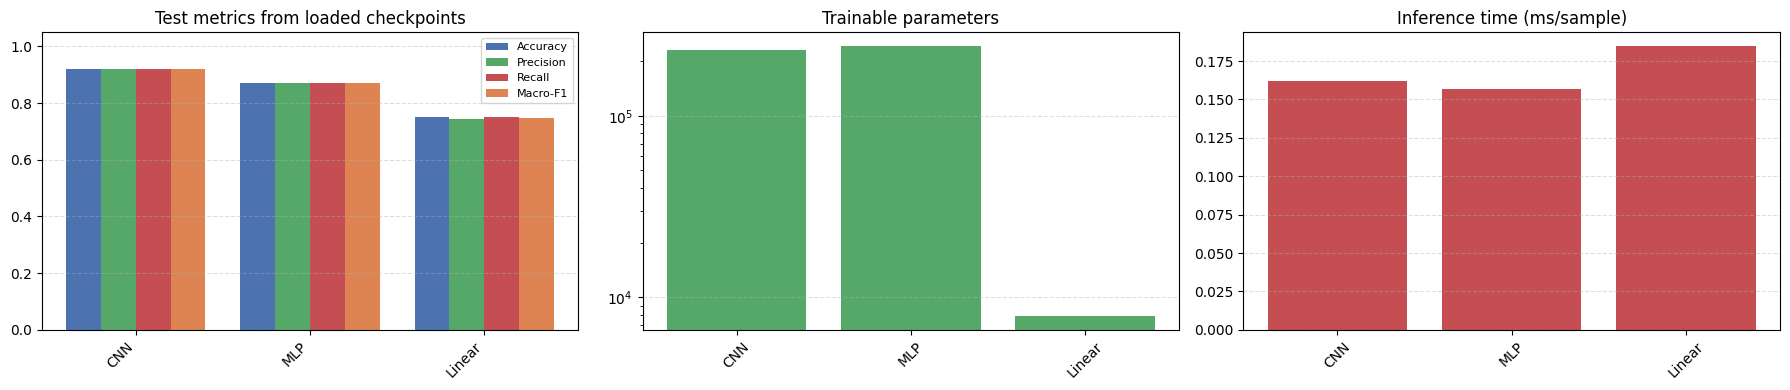

In [ ]:
if len(results_df) > 0:
    print(results_df.to_string(index=False))

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    x = np.arange(len(results_df)); width = 0.2
    axes[0].bar(x - 1.5 * width, results_df["test_accuracy_mean"], width, label="Accuracy", color="#4C72B0")
    axes[0].bar(x - 0.5 * width, results_df["test_precision_mean"], width, label="Precision", color="#55A868")
    axes[0].bar(x + 0.5 * width, results_df["test_recall_mean"], width, label="Recall", color="#C44E52")
    axes[0].bar(x + 1.5 * width, results_df["test_macro_f1_mean"], width, label="Macro-F1", color="#DD8452")
    axes[0].set_xticks(x); axes[0].set_xticklabels(results_df["model"], rotation=45, ha="right")
    axes[0].set_title("Test metrics from loaded checkpoints"); axes[0].set_ylim(0, 1.05); axes[0].legend(fontsize=8); axes[0].grid(axis="y", linestyle="--", alpha=0.4)

    axes[1].bar(results_df["model"], results_df["params"], color="#55A868")
    axes[1].set_title("Trainable parameters"); axes[1].set_yscale("log"); axes[1].tick_params(axis="x", rotation=45); axes[1].grid(axis="y", linestyle="--", alpha=0.4)

    axes[2].bar(results_df["model"], results_df["inference_ms_per_sample"], color="#C44E52")
    axes[2].set_title("Inference time (ms/sample)"); axes[2].tick_params(axis="x", rotation=45); axes[2].grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "14_model_comparison.png"), dpi=150, bbox_inches="tight"); plt.show()
else:
    print("No evaluated checkpoint results available.")


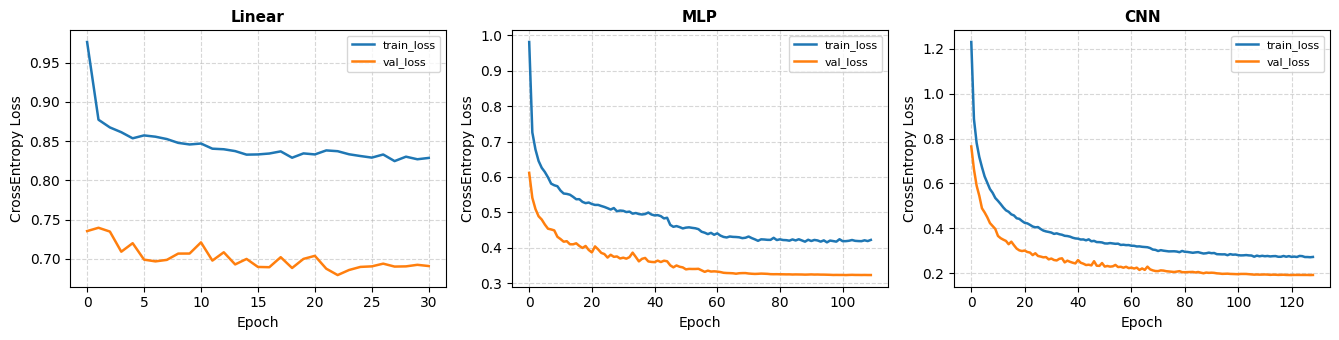

In [ ]:
plot_histories = {k: v for k, v in histories.items() if v and "train_loss" in v and len(v["train_loss"]) > 0}
if plot_histories:
    fig, axes = plt.subplots(1, len(plot_histories), figsize=(4.5 * len(plot_histories), 3.5), sharey=False)
    if len(plot_histories) == 1: axes = [axes]
    for ax, (name, h) in zip(axes, plot_histories.items()):
        ax.plot(h["train_loss"], label="train_loss", color="#1f77b4", linewidth=1.8)
        ax.plot(h["val_loss"], label="val_loss", color="#ff7f0e", linewidth=1.8)
        ax.set_title(name, fontsize=11, fontweight="bold"); ax.set_xlabel("Epoch"); ax.set_ylabel("CrossEntropy Loss")
        ax.legend(fontsize=8); ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "14_training_curves.png"), dpi=150, bbox_inches="tight"); plt.show()
else:
    print("No history stored in the evaluated checkpoint(s).")


## 15. Confusion matrices


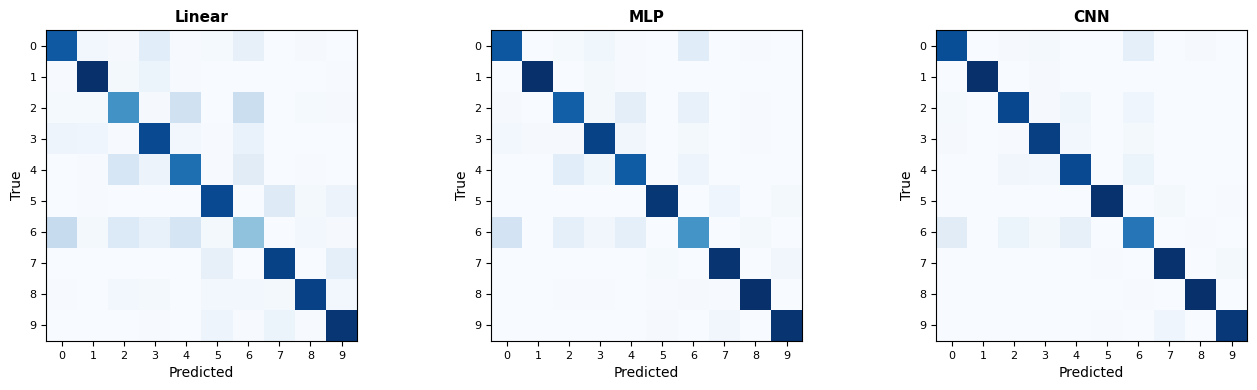

In [ ]:
if trained_models:
    fig, axes = plt.subplots(1, len(trained_models), figsize=(4.5 * len(trained_models), 4))
    if len(trained_models) == 1:
        axes = [axes]
    for ax, (name, d) in zip(axes, trained_models.items()):
        cm = confusion_matrix(d["y_true"], d["y_pred"])
        im = ax.imshow(cm, cmap="Blues")
        ax.set_title(name, fontsize=11, fontweight="bold")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_xticks(range(NUM_CLASSES))
        ax.set_yticks(range(NUM_CLASSES))
        ax.set_xticklabels(range(NUM_CLASSES), fontsize=8)
        ax.set_yticklabels(range(NUM_CLASSES), fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "15_confusion_matrices.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No trained models available for confusion matrix.")


## 16. Qualitative results


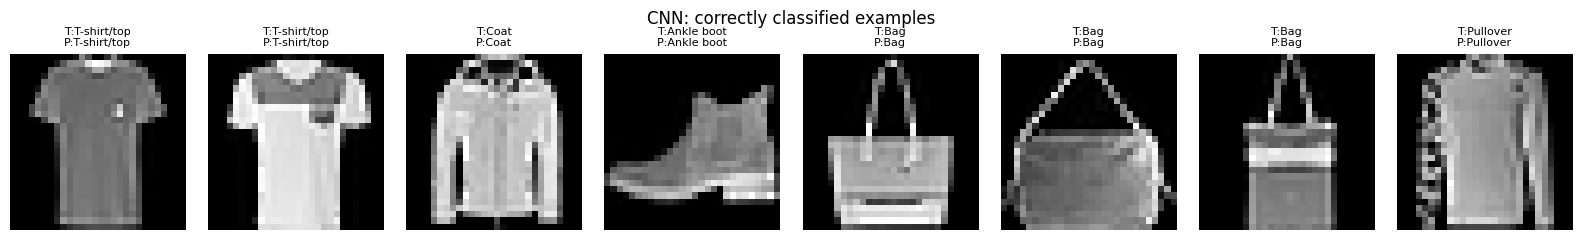

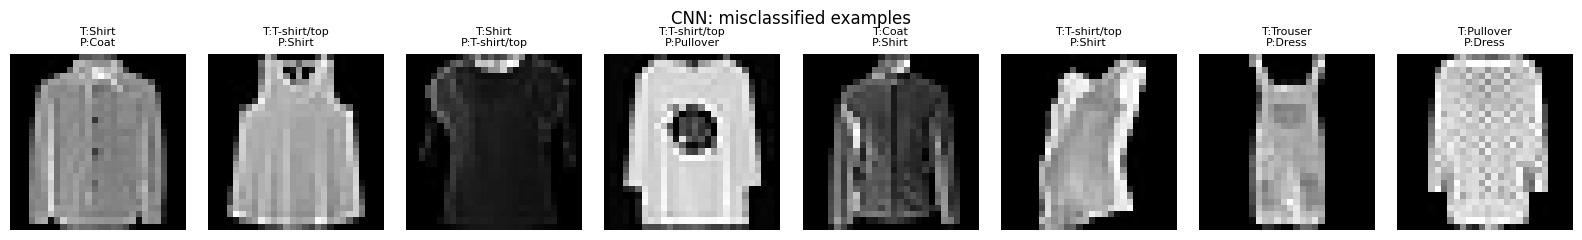

In [ ]:
if len(results_df) > 0 and len(trained_models) > 0:
    best_name = results_df.sort_values('test_macro_f1_mean', ascending=False).iloc[0]['model']
    best_model = trained_models[best_name]["model"]
    y_true = trained_models[best_name]["y_true"]
    y_pred = trained_models[best_name]["y_pred"]

    correct_idx = np.where(y_true == y_pred)[0]
    wrong_idx = np.where(y_true != y_pred)[0]

    def show_examples(indices, title, n=8, save_name=None):
        n = min(n, len(indices))
        chosen = np.random.choice(indices, size=n, replace=False) if n > 0 else []
        fig, axes = plt.subplots(1, max(n, 1), figsize=(2 * max(n, 1), 2.4))
        if n == 1:
            axes = [axes]
        for ax, idx in zip(axes, chosen):
            ax.imshow(test_images[idx], cmap="gray")
            ax.set_title(f"T:{CLASS_NAMES[y_true[idx]]}\nP:{CLASS_NAMES[y_pred[idx]]}", fontsize=8)
            ax.axis("off")
        plt.suptitle(title)
        plt.tight_layout()
        if save_name:
            plt.savefig(os.path.join(FIG_DIR, save_name), dpi=150, bbox_inches="tight")
        plt.show()

    show_examples(correct_idx, f"{best_name}: correctly classified examples", save_name="16_qualitative_correct.png")
    show_examples(wrong_idx, f"{best_name}: misclassified examples", save_name="16_qualitative_incorrect.png")
else:
    print("No model results available for qualitative display.")
